# Business and Data Understanding

Swiggy processes millions of food-delivery journeys across hundreds of cities every month. 
Accurate Estimated Time of Arrival (ETA) at order placement and during delivery is core to the 
customer experience — it affects conversion, cancellations, ratings, and retention. Today’s ETA 
accuracy suffers from many sources of uncertainty: highly variable traffic patterns, weather 
events, restaurant preparation variability, rider behaviour and skill, order batching/multiple 
deliveries, and city-specific operational constraints. Inaccurate ETAs cause: 
* Reduced customer trust and lower repeat orders. 
* Increased cancellations and refund costs. 
* Higher support volume and operational interventions. 
* Sub-optimal rider allocation and increased rider idle or overtime costs. 

# Problem Statement

Swiggy’s objective is to predict the delivery time (minutes) per order at the moment of order 
placement (and update it dynamically), with business-grade accuracy and uncertainty estimates 
so the platform can 
* show reliable ETAs to customers 
* optimize rider allocation.

# Importing Libraries

In [1]:
#Data Manipulation
import numpy as np
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Ignoring Warnings
import warnings
warnings.filterwarnings('ignore')

#For displaying all columns
pd.set_option('display.max_columns', None)

#For displaying all rows if required
pd.set_option('display.max_rows',100)

# Loading Data

In [2]:
df = pd.read_csv(r"D:\Studies\Innomatics (Data Science) Course\Machine Learning\Swiggy Delivery Time Prediction Project\swiggy_demographic (1).csv")

In [3]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


# Data Cleaning

In [4]:
df.shape  #Shape of Dataset

(45502, 26)

In [5]:
df.head(10)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
5,HYDRES09DEL03,22.0,4.8,17.431668,78.408321,17.461668,78.438321,2022-03-11,cloudy,jam,0,buffet,motorcycle,1.0,no,urban,26,HYD,11,3,friday,0,10.0,21.0,night,4.610365
6,RANCHIRES15DEL01,33.0,4.7,23.369746,85.339820,23.479746,85.449820,2022-03-04,fog,jam,1,meal,scooter,1.0,no,metropolitian,40,RANCHI,4,3,friday,0,15.0,19.0,evening,16.600361
7,MYSRES15DEL02,35.0,4.6,12.352058,76.606650,12.482058,76.736650,2022-03-14,cloudy,medium,2,meal,motorcycle,1.0,no,metropolitian,32,MYS,14,3,monday,0,5.0,17.0,evening,20.205253
8,HYDRES05DEL02,22.0,4.8,17.433809,78.386744,17.563809,78.516744,2022-03-20,stormy,jam,0,buffet,motorcycle,1.0,no,metropolitian,34,HYD,20,3,sunday,1,10.0,20.0,night,19.975520
9,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,fog,jam,2,snack,motorcycle,3.0,no,metropolitian,46,DEH,12,2,saturday,1,15.0,21.0,night,10.280582


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,43648.0,29.555008,5.761482,20.000000,25.000000,30.000000,35.000000,39.000000
ratings,43594.0,4.635287,0.313827,2.500000,4.500000,4.700000,4.900000,5.000000
restaurant_latitude,41872.0,18.913696,5.467265,9.957144,12.986047,19.065838,22.751234,30.914057
restaurant_longitude,41872.0,76.921664,3.503107,72.768726,73.897902,76.618203,78.368855,88.433452
delivery_latitude,41872.0,18.977356,5.469056,9.967144,13.065996,19.124049,22.820040,31.054057
delivery_longitude,41872.0,76.985325,3.503260,72.778726,73.940327,76.662620,78.405467,88.563452
vehicle_condition,45502.0,1.019406,0.835229,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44509.0,0.744928,0.572488,0.000000,0.000000,1.000000,1.000000,3.000000
time_taken,45502.0,26.297591,9.386419,10.000000,19.000000,26.000000,32.000000,54.000000
order_day,45502.0,13.811657,8.709540,1.000000,6.000000,13.000000,20.000000,31.000000


In [8]:
df.dtypes

rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
weather                  object
traffic                  object
vehicle_condition         int64
type_of_order            object
type_of_vehicle          object
multiple_deliveries     float64
festival                 object
city_type                object
time_taken                int64
city_name                object
order_day                 int64
order_month               int64
order_day_of_week        object
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day        object
distance                float64
dtype: object

In [9]:
df.isnull().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['time_taken'].head()

0    24
1    33
2    26
3    21
4    30
Name: time_taken, dtype: int64

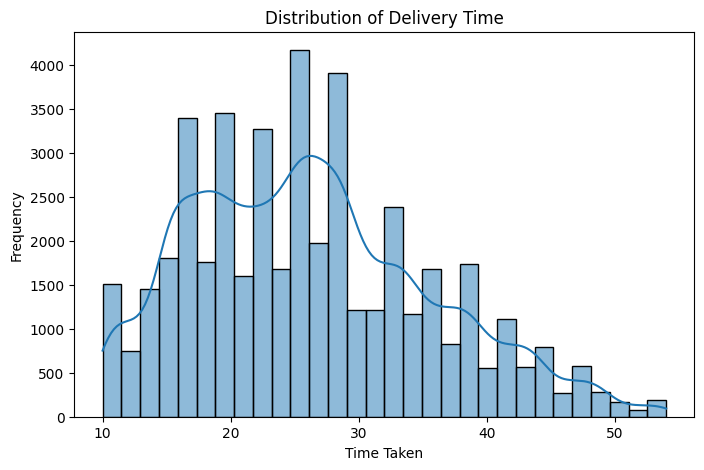

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["time_taken"], bins=30, kde=True)

plt.title("Distribution of Delivery Time")

plt.xlabel("Time Taken")

plt.ylabel("Frequency")

plt.show()

In [13]:
df1 = df.copy()

df1.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [14]:
df1.shape

(45502, 26)

In [15]:
len(df1)

45502

In [16]:
df1['rider_id'].unique()

array(['INDORES13DEL02 ', 'BANGRES18DEL02 ', 'BANGRES19DEL01 ', ...,
       'KOCRES04DEL01 ', 'BHPRES06DEL03 ', 'GOARES03DEL03 '],
      shape=(1320,), dtype=object)

## Removing Irrelevant Features

In [17]:
df1.drop(
    columns=[
        "rider_id",
        "order_date",
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_latitude",
        "delivery_longitude"
    ],
    inplace=True
)

df1.head()

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [18]:
duplicate_count = df1.duplicated().sum()
print("Duplicate Records :", duplicate_count)

Duplicate Records : 0


# Feature Engineering

## Feature: Peak Hour

In [19]:
#Peak Hour Indicator
df1["Peak_Hour"] = df1["order_time_hour"].apply(
    lambda x: 1 if x in [12,13,19,20,21] else 0
)

## Feature: Delivery Load

In [20]:
#Delivery Load
df1["Delivery_Load"] = np.where(
    df1["multiple_deliveries"] > 1,
    "High",
    "Low"
)

## Checking New Features

In [21]:
df1.head(10)

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,Peak_Hour,Delivery_Load
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,0,Low
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,1,Low
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,0,Low
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,0,Low
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,1,Low
5,22.0,4.8,cloudy,jam,0,buffet,motorcycle,1.0,no,urban,26,HYD,11,3,friday,0,10.0,21.0,night,4.610365,1,Low
6,33.0,4.7,fog,jam,1,meal,scooter,1.0,no,metropolitian,40,RANCHI,4,3,friday,0,15.0,19.0,evening,16.600361,1,Low
7,35.0,4.6,cloudy,medium,2,meal,motorcycle,1.0,no,metropolitian,32,MYS,14,3,monday,0,5.0,17.0,evening,20.205253,0,Low
8,22.0,4.8,stormy,jam,0,buffet,motorcycle,1.0,no,metropolitian,34,HYD,20,3,sunday,1,10.0,20.0,night,19.975520,1,Low
9,36.0,4.2,fog,jam,2,snack,motorcycle,3.0,no,metropolitian,46,DEH,12,2,saturday,1,15.0,21.0,night,10.280582,1,High


In [22]:
print('Final Dataset Shape :',df1.shape)

Final Dataset Shape : (45502, 22)


In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  43648 non-null  float64
 1   ratings              43594 non-null  float64
 2   weather              44977 non-null  object 
 3   traffic              44992 non-null  object 
 4   vehicle_condition    45502 non-null  int64  
 5   type_of_order        45502 non-null  object 
 6   type_of_vehicle      45502 non-null  object 
 7   multiple_deliveries  44509 non-null  float64
 8   festival             45274 non-null  object 
 9   city_type            44304 non-null  object 
 10  time_taken           45502 non-null  int64  
 11  city_name            45502 non-null  object 
 12  order_day            45502 non-null  int64  
 13  order_month          45502 non-null  int64  
 14  order_day_of_week    45502 non-null  object 
 15  is_weekend           45502 non-null 

## Checking Missing Values

In [24]:
df1.isnull().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
time_taken                0
city_name                 0
order_day                 0
order_month               0
order_day_of_week         0
is_weekend                0
pickup_time_minutes    1640
order_time_hour        1640
order_time_of_day         0
distance               3630
Peak_Hour                 0
Delivery_Load             0
dtype: int64

# Without Pipeline

## Separate Features and Target

In [25]:
X = df1.drop("time_taken",axis=1)
y = df1["time_taken"]

## Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=23)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (36401, 21)
Testing Shape : (9101, 21)


## Create Copies

In [27]:
X_train_preprocessed = X_train.copy()
X_test_preprocessed = X_test.copy()

## Separate Numerical And Catgorical Features

In [28]:
num_features = X_train_preprocessed.select_dtypes(include=["int64","float64"]).columns

cat_features = X_train_preprocessed.select_dtypes(include=["object","category"]).columns

print("Numerical Features")
print(num_features)

print()

print("Categorical Features")
print(cat_features)

Numerical Features
Index(['age', 'ratings', 'vehicle_condition', 'multiple_deliveries',
       'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'distance', 'Peak_Hour'],
      dtype='object')

Categorical Features
Index(['weather', 'traffic', 'type_of_order', 'type_of_vehicle', 'festival',
       'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day',
       'Delivery_Load'],
      dtype='object')


## Missing Value Imputation

### Numerical

In [29]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")

X_train_preprocessed[num_features] = median_imputer.fit_transform(
    X_train_preprocessed[num_features]
)

X_test_preprocessed[num_features] = median_imputer.transform(
    X_test_preprocessed[num_features]
)

### Categorical

In [30]:
mode_imputer = SimpleImputer(strategy="most_frequent")

X_train_preprocessed[cat_features] = mode_imputer.fit_transform(
    X_train_preprocessed[cat_features]
)

X_test_preprocessed[cat_features] = mode_imputer.transform(
    X_test_preprocessed[cat_features]
)

## Verifying Missing Values

In [31]:
print("Training Missing Values")
print(X_train_preprocessed.isnull().sum())

print()

print("Testing Missing Values")
print(X_test_preprocessed.isnull().sum())

Training Missing Values
age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
city_name              0
order_day              0
order_month            0
order_day_of_week      0
is_weekend             0
pickup_time_minutes    0
order_time_hour        0
order_time_of_day      0
distance               0
Peak_Hour              0
Delivery_Load          0
dtype: int64

Testing Missing Values
age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
city_name              0
order_day              0
order_month            0
order_day_of_week      0
is_weekend             0
pickup_time_minutes    0
order_time_hou

## Outlier Treatment

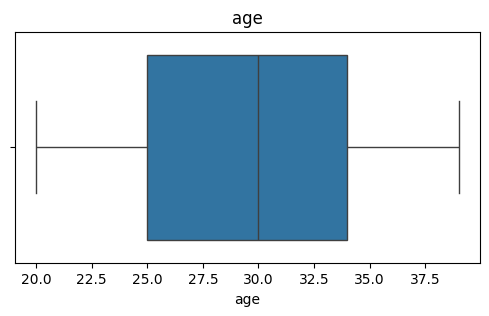

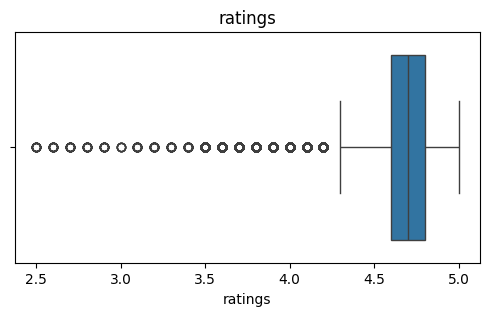

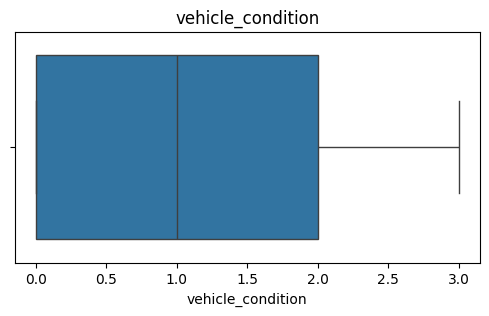

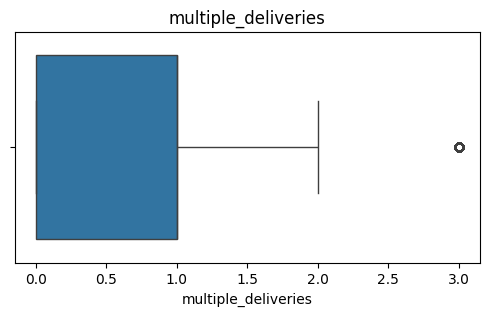

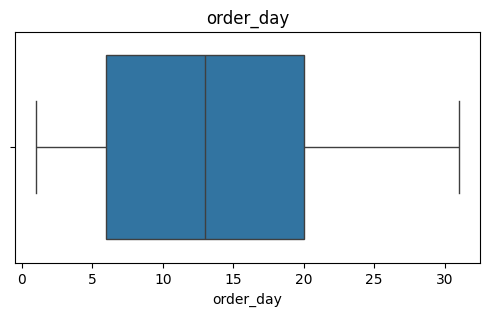

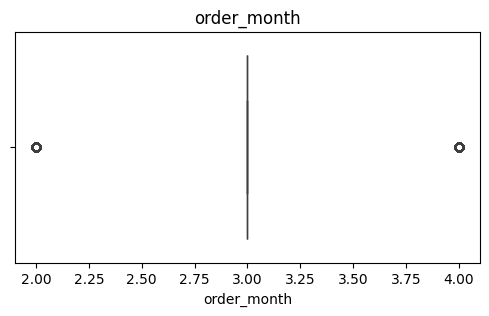

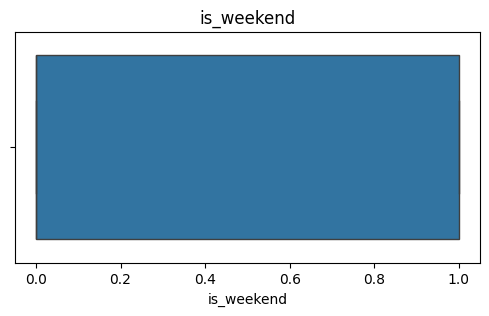

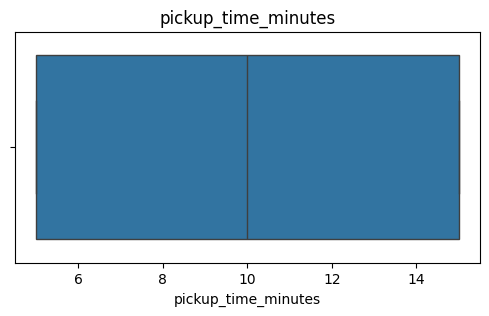

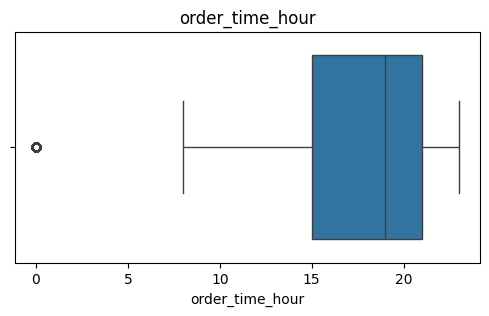

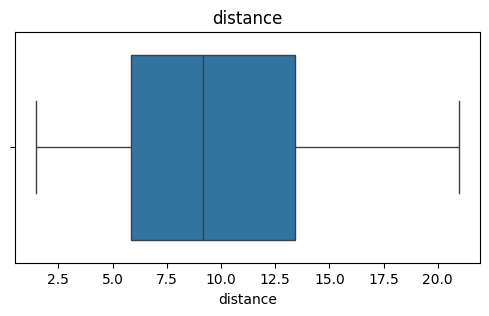

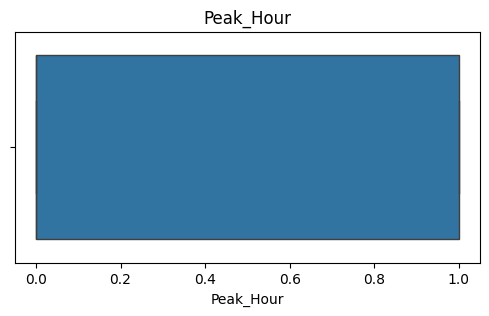

In [32]:
for column in num_features:

    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=X_train_preprocessed[column])

    plt.title(column)

    plt.show()

## Identify Encoding Strategy

In [33]:
for column in cat_features:

    print(f"\n{column}")

    print(X_train_preprocessed[column].unique())


weather
['fog' 'sunny' 'sandstorms' 'cloudy' 'stormy' 'windy']

traffic
['medium' 'low' 'jam' 'high']

type_of_order
['snack' 'drinks' 'buffet' 'meal']

type_of_vehicle
['motorcycle' 'electric_scooter' 'scooter' 'bicycle']

festival
['no' 'yes']

city_type
['metropolitian' 'urban' 'semi-urban']

city_name
['CHEN' 'KNP' 'BANG' 'SUR' 'COIMB' 'PUNE' 'INDO' 'VAD' 'RANCHI' 'DEH'
 'MYS' 'HYD' 'JAP' 'AURG' 'GOA' 'LUDH' 'ALH' 'MUM' 'BHP' 'AGR' 'KOL' 'KOC']

order_day_of_week
['sunday' 'tuesday' 'friday' 'monday' 'wednesday' 'thursday' 'saturday']

order_time_of_day
['evening' 'night' 'morning' 'afternoon' 'after_midnight']

Delivery_Load
['Low' 'High']


### Updating feature lists

In [34]:
num_features = X_train_preprocessed.select_dtypes(include=["int64", "float64"]).columns

cat_features = X_train_preprocessed.select_dtypes(include=["object", "category"]).columns

## Final Encoding Lists

In [35]:
ordinal_features = [
    "traffic",
    "city_type"
]

nominal_features = [
    "weather",
    "type_of_order",
    "type_of_vehicle",
    "festival",
    "city_name",
    "order_day_of_week",
    "order_time_of_day",
    "Delivery_Load"
]

## Ordinal Encoding

In [36]:
df1['city_type'].unique()

array(['urban', 'metropolitian', 'semi-urban', nan], dtype=object)

In [37]:
from sklearn.preprocessing import OrdinalEncoder

In [38]:
ordinal_features = [
    "traffic",
    "city_type"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["low", "medium", "high", "jam"],
        ["semi-urban", "urban", "metropolitian"]
    ]
)

X_train_preprocessed[ordinal_features] = ordinal_encoder.fit_transform(
    X_train_preprocessed[ordinal_features]
)

X_test_preprocessed[ordinal_features] = ordinal_encoder.transform(
    X_test_preprocessed[ordinal_features]
)

## One-Hot Encoding

### Define Nominal Features

In [39]:
nominal_features = [
    "weather",
    "type_of_order",
    "type_of_vehicle",
    "festival",
    "city_name",
    "order_day_of_week",
    "order_time_of_day",
    "Delivery_Load"
]

nominal_features

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_name',
 'order_day_of_week',
 'order_time_of_day',
 'Delivery_Load']

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
onehot_encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_encoded = onehot_encoder.fit_transform(
    X_train_preprocessed[nominal_features]
)

X_test_encoded = onehot_encoder.transform(
    X_test_preprocessed[nominal_features]
)

In [42]:
encoded_columns = onehot_encoder.get_feature_names_out(
    nominal_features
)

encoded_columns

array(['weather_fog', 'weather_sandstorms', 'weather_stormy',
       'weather_sunny', 'weather_windy', 'type_of_order_drinks',
       'type_of_order_meal', 'type_of_order_snack',
       'type_of_vehicle_electric_scooter', 'type_of_vehicle_motorcycle',
       'type_of_vehicle_scooter', 'festival_yes', 'city_name_ALH',
       'city_name_AURG', 'city_name_BANG', 'city_name_BHP',
       'city_name_CHEN', 'city_name_COIMB', 'city_name_DEH',
       'city_name_GOA', 'city_name_HYD', 'city_name_INDO',
       'city_name_JAP', 'city_name_KNP', 'city_name_KOC', 'city_name_KOL',
       'city_name_LUDH', 'city_name_MUM', 'city_name_MYS',
       'city_name_PUNE', 'city_name_RANCHI', 'city_name_SUR',
       'city_name_VAD', 'order_day_of_week_monday',
       'order_day_of_week_saturday', 'order_day_of_week_sunday',
       'order_day_of_week_thursday', 'order_day_of_week_tuesday',
       'order_day_of_week_wednesday', 'order_time_of_day_afternoon',
       'order_time_of_day_evening', 'order_time_of_da

### Converting Arrays into DataFrames

In [43]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train_preprocessed.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test_preprocessed.index
)

### Removing Original Nominal Columns

In [44]:
X_train_preprocessed.drop(
    columns=nominal_features,
    inplace=True
)

X_test_preprocessed.drop(
    columns=nominal_features,
    inplace=True
)

### Concatenating Encoded Features

In [45]:
X_train_preprocessed = pd.concat(
    [X_train_preprocessed, X_train_encoded],
    axis=1
)

X_test_preprocessed = pd.concat(
    [X_test_preprocessed, X_test_encoded],
    axis=1
)

### Verifying Final Dataset

In [46]:
print("Training Shape :", X_train_preprocessed.shape)
print("Testing Shape :", X_test_preprocessed.shape)

X_train_preprocessed.head(10)

Training Shape : (36401, 57)
Testing Shape : (9101, 57)


,age,ratings,traffic,vehicle_condition,multiple_deliveries,city_type,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance,Peak_Hour,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,type_of_order_meal,type_of_order_snack,type_of_vehicle_electric_scooter,type_of_vehicle_motorcycle,type_of_vehicle_scooter,festival_yes,city_name_ALH,city_name_AURG,city_name_BANG,city_name_BHP,city_name_CHEN,city_name_COIMB,city_name_DEH,city_name_GOA,city_name_HYD,city_name_INDO,city_name_JAP,city_name_KNP,city_name_KOC,city_name_KOL,city_name_LUDH,city_name_MUM,city_name_MYS,city_name_PUNE,city_name_RANCHI,city_name_SUR,city_name_VAD,order_day_of_week_monday,order_day_of_week_saturday,order_day_of_week_sunday,order_day_of_week_thursday,order_day_of_week_tuesday,order_day_of_week_wednesday,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,Delivery_Load_Low
36004,30.0,4.5,1.0,2.0,1.0,2.0,13.0,3.0,1.0,15.0,18.0,7.761498,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
24372,26.0,5.0,0.0,1.0,1.0,2.0,15.0,2.0,0.0,10.0,23.0,4.476697,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
18065,20.0,4.7,3.0,0.0,1.0,2.0,27.0,3.0,1.0,5.0,19.0,10.867476,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
31552,31.0,3.9,0.0,2.0,1.0,2.0,18.0,3.0,0.0,5.0,22.0,20.178267,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1806,29.0,4.9,0.0,0.0,1.0,2.0,14.0,3.0,0.0,15.0,22.0,12.161512,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
28427,36.0,5.0,3.0,1.0,1.0,2.0,9.0,3.0,0.0,15.0,19.0,7.790489,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4331,22.0,4.7,1.0,1.0,1.0,2.0,28.0,3.0,0.0,5.0,17.0,4.674220,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2612,21.0,4.8,0.0,1.0,1.0,2.0,17.0,3.0,0.0,5.0,8.0,3.104804,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15933,25.0,4.5,3.0,0.0,1.0,2.0,21.0,3.0,0.0,10.0,20.0,4.595394,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
37560,30.0,4.7,0.0,1.0,1.0,2.0,25.0,3.0,0.0,5.0,22.0,12.100288,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [47]:
X_train_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36401 entries, 36004 to 41555
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               36401 non-null  float64
 1   ratings                           36401 non-null  float64
 2   traffic                           36401 non-null  float64
 3   vehicle_condition                 36401 non-null  float64
 4   multiple_deliveries               36401 non-null  float64
 5   city_type                         36401 non-null  float64
 6   order_day                         36401 non-null  float64
 7   order_month                       36401 non-null  float64
 8   is_weekend                        36401 non-null  float64
 9   pickup_time_minutes               36401 non-null  float64
 10  order_time_hour                   36401 non-null  float64
 11  distance                          36401 non-null  float64
 12  Peak_

In [48]:
X_train_preprocessed.isnull().sum().sum()

np.int64(0)

In [49]:
X_train_preprocessed.dtypes.value_counts()

float64    57
Name: count, dtype: int64

In [50]:
print("Training Shape :", X_train_preprocessed.shape)
print("Testing Shape :", X_test_preprocessed.shape)

print("\nMissing Values in Training :", X_train_preprocessed.isnull().sum().sum())
print("Missing Values in Testing :", X_test_preprocessed.isnull().sum().sum())

print("\nData Types")
print(X_train_preprocessed.dtypes.value_counts())

Training Shape : (36401, 57)
Testing Shape : (9101, 57)

Missing Values in Training : 0
Missing Values in Testing : 0

Data Types
float64    57
Name: count, dtype: int64


# Model Building (Without Pipeline)

## Importing Required Libraries

In [51]:
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Model Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Model Building

## Linear Regression

In [52]:
linear_model = LinearRegression()

linear_model.fit(X_train_preprocessed,y_train)

y_train_pred = linear_model.predict(X_train_preprocessed)

y_test_pred = linear_model.predict(X_test_preprocessed)

### Evaluation

In [53]:
lr_train_r2 = r2_score(y_train,y_train_pred)

lr_test_r2 = r2_score(y_test,y_test_pred)

lr_mae = mean_absolute_error(y_test,y_test_pred)

lr_mse = mean_squared_error(y_test,y_test_pred)

lr_rmse = np.sqrt(lr_mse)

### Result

In [54]:
print("Linear Regression Performance")

print("Training R² :", lr_train_r2)

print("Testing R² :", lr_test_r2)

print("MAE :", lr_mae)

print("MSE :", lr_mse)

print("RMSE :", lr_rmse)

Linear Regression Performance
Training R² : 0.5820398056629803
Testing R² : 0.5933010716873213
MAE : 4.7994163677686625
MSE : 36.159717561901715
RMSE : 6.013295066924765


## Decision Tree Regressor

In [55]:
dt_model = DecisionTreeRegressor(random_state=23,max_depth=10,min_samples_split=5,
                                 min_samples_leaf=2)

dt_model.fit(X_train_preprocessed,y_train)

y_train_pred_dt = dt_model.predict(X_train_preprocessed)

y_test_pred_dt = dt_model.predict(X_test_preprocessed)

### Evaluation

In [56]:
dt_train_r2 = r2_score(y_train,y_train_pred_dt)

dt_test_r2 = r2_score(y_test,y_test_pred_dt)

dt_mae = mean_absolute_error(y_test,y_test_pred_dt)

dt_mse = mean_squared_error(y_test,y_test_pred_dt)

dt_rmse = np.sqrt(dt_mse)

### Result

In [57]:
print("Decision Tree Regressor Performance")

print("Training R² Score :", dt_train_r2)
print("Testing R² Score  :", dt_test_r2)
print("MAE               :", dt_mae)
print("MSE               :", dt_mse)
print("RMSE              :", dt_rmse)

Decision Tree Regressor Performance
Training R² Score : 0.7694225287737609
Testing R² Score  : 0.7590769444418115
MAE               : 3.6137521496610816
MSE               : 21.420537495089494
RMSE              : 4.628232653517917


## Random Forest Regressor

In [58]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

rf_model.fit(X_train_preprocessed,y_train)

y_train_pred_rf = rf_model.predict(X_train_preprocessed)

y_test_pred_rf = rf_model.predict(X_test_preprocessed)

### Evaluation

In [59]:
rf_train_r2 = r2_score(y_train,y_train_pred_rf)

rf_test_r2 = r2_score(y_test,y_test_pred_rf)

rf_mae = mean_absolute_error(y_test,y_test_pred_rf)

rf_mse = mean_squared_error(y_test,y_test_pred_rf)

rf_rmse = np.sqrt(rf_mse)

### Results

In [60]:
print("Random Forest Regressor Performance")

print("Training R² Score :", rf_train_r2)
print("Testing R² Score  :", rf_test_r2)
print("MAE               :", rf_mae)
print("MSE               :", rf_mse)
print("RMSE              :", rf_rmse)

Random Forest Regressor Performance
Training R² Score : 0.9722038876670318
Testing R² Score  : 0.806265730555195
MAE               : 3.268421052631579
MSE               : 17.224969080320843
RMSE              : 4.1502974688955545


## XGBoost Regressor

In [61]:
xgb_model = XGBRegressor(n_estimators=100,learning_rate=0.1,
    max_depth=6,random_state=23,objective="reg:squarederror")

xgb_model.fit(X_train_preprocessed,y_train)

y_train_pred_xgb = xgb_model.predict(X_train_preprocessed)

y_test_pred_xgb = xgb_model.predict(X_test_preprocessed)

### Evaluation

In [62]:
xgb_train_r2 = r2_score(y_train,y_train_pred_xgb)

xgb_test_r2 = r2_score(y_test,y_test_pred_xgb)

xgb_mae = mean_absolute_error(y_test,y_test_pred_xgb)

xgb_mse = mean_squared_error(y_test,y_test_pred_xgb)

xgb_rmse = np.sqrt(xgb_mse)

### Result

In [63]:
print("XGBoost Regressor Performance")

print("Training R² Score :", xgb_train_r2)
print("Testing R² Score  :", xgb_test_r2)
print("MAE               :", xgb_mae)
print("MSE               :", xgb_mse)
print("RMSE              :", xgb_rmse)

XGBoost Regressor Performance
Training R² Score : 0.8229895830154419
Testing R² Score  : 0.8086379766464233
MAE               : 3.2847180366516113
MSE               : 17.01405143737793
RMSE              : 4.124809260726844


## Model Comparison

In [64]:
model_results = pd.DataFrame({
    
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    
    "Training R²": [lr_train_r2,dt_train_r2,rf_train_r2,xgb_train_r2],
    
    "Testing R²": [lr_test_r2,dt_test_r2,rf_test_r2,xgb_test_r2],
    
    "MAE": [lr_mae,dt_mae,rf_mae,xgb_mae],
    
    "MSE": [lr_mse,dt_mse,rf_mse,xgb_mse],
    
    "RMSE": [lr_rmse,dt_rmse,rf_rmse,xgb_rmse]
})

model_results

,Model,Training R²,Testing R²,MAE,MSE,RMSE
0,Linear Regression,0.582040,0.593301,4.799416,36.159718,6.013295
1,Decision Tree,0.769423,0.759077,3.613752,21.420537,4.628233
2,Random Forest,0.972204,0.806266,3.268421,17.224969,4.150297
3,XGBoost,0.822990,0.808638,3.284718,17.014051,4.124809


### Sort by Test R square

In [65]:
model_results = model_results.sort_values(by="Testing R²",ascending=False)

model_results

,Model,Training R²,Testing R²,MAE,MSE,RMSE
3,XGBoost,0.822990,0.808638,3.284718,17.014051,4.124809
2,Random Forest,0.972204,0.806266,3.268421,17.224969,4.150297
1,Decision Tree,0.769423,0.759077,3.613752,21.420537,4.628233
0,Linear Regression,0.582040,0.593301,4.799416,36.159718,6.013295


### Visualizing Model Performance

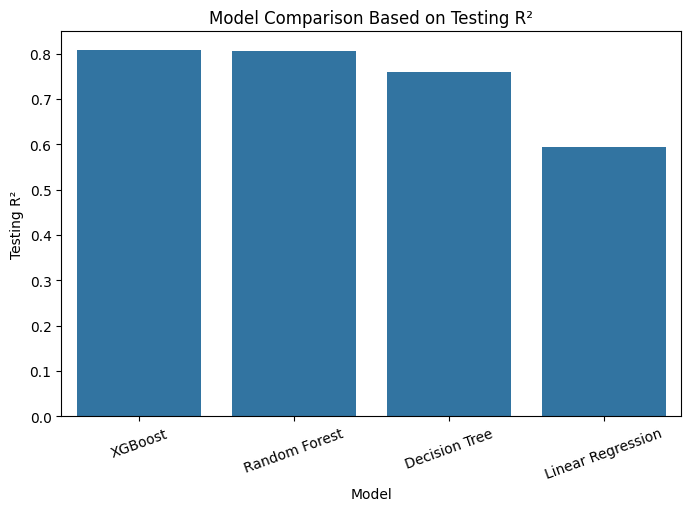

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(data=model_results,x="Model",y="Testing R²")

plt.title("Model Comparison Based on Testing R²")

plt.xticks(rotation=20)

plt.show()

## Feature Selection

### Recursive Feature Elimination

In [67]:
from sklearn.feature_selection import RFE

### Creating Based Model

In [68]:
xgb_rfe = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

### Creating the RFE Object

In [69]:
rfe = RFE(
    estimator=xgb_rfe,
    n_features_to_select=30,
    step=1
)

### Fitting RFE

In [70]:
rfe.fit(
    X_train_preprocessed,
    y_train
)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).","XGBRegressor(...ree=None, ...)"
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",30
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None


### Viewing Selected Features

In [71]:
selected_features = X_train_preprocessed.columns[rfe.support_]

print("Selected Features:\n")

for feature in selected_features:
    print(feature)

Selected Features:

age
ratings
traffic
vehicle_condition
multiple_deliveries
city_type
order_day
order_month
order_time_hour
distance
Peak_Hour
weather_fog
weather_sandstorms
weather_stormy
weather_sunny
weather_windy
festival_yes
city_name_CHEN
city_name_DEH
city_name_KOL
city_name_MYS
city_name_RANCHI
city_name_VAD
order_day_of_week_monday
order_day_of_week_saturday
order_day_of_week_sunday
order_day_of_week_wednesday
order_time_of_day_afternoon
order_time_of_day_evening
order_time_of_day_morning


### Number of Selected Features

In [72]:
print("Total Selected Features:", len(selected_features))

Total Selected Features: 30


### Creating New Datasets

In [73]:
X_train_selected = X_train_preprocessed[selected_features]

X_test_selected = X_test_preprocessed[selected_features]

### Training the Tuned XGBoost Again

In [74]:
best_xgb_selected = XGBRegressor(
    random_state=23,
    objective="reg:squarederror"
)

best_xgb_selected.fit(
    X_train_selected,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### Evaluation

In [75]:
y_train_pred_selected = best_xgb_selected.predict(X_train_selected)

y_test_pred_selected = best_xgb_selected.predict(X_test_selected)

### Import Metrics

In [76]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

### Calculating the Missing Variables

In [77]:
selected_train_r2 = r2_score(
    y_train,
    y_train_pred_selected
)

selected_test_r2 = r2_score(
    y_test,
    y_test_pred_selected
)

selected_mae = mean_absolute_error(
    y_test,
    y_test_pred_selected
)

selected_mse = mean_squared_error(
    y_test,
    y_test_pred_selected
)

selected_rmse = np.sqrt(selected_mse)

### Compare Before and After Feature Selection

In [78]:
feature_selection_results = pd.DataFrame({
    "Metric": ["Training R²", "Testing R²", "MAE", "RMSE"],
    "Before RFE": [
        xgb_train_r2,
        xgb_test_r2,
        xgb_mae,
        xgb_rmse
    ],
    "After RFE": [
        selected_train_r2,
        selected_test_r2,
        selected_mae,
        selected_rmse
    ]
})

feature_selection_results

,Metric,Before RFE,After RFE
0,Training R²,0.822990,0.854355
1,Testing R²,0.808638,0.810061
2,MAE,3.284718,3.259268
3,RMSE,4.124809,4.109439


In [79]:
print("Number of Selected Features:", len(selected_features))
print(selected_features)

Number of Selected Features: 30
Index(['age', 'ratings', 'traffic', 'vehicle_condition', 'multiple_deliveries',
       'city_type', 'order_day', 'order_month', 'order_time_hour', 'distance',
       'Peak_Hour', 'weather_fog', 'weather_sandstorms', 'weather_stormy',
       'weather_sunny', 'weather_windy', 'festival_yes', 'city_name_CHEN',
       'city_name_DEH', 'city_name_KOL', 'city_name_MYS', 'city_name_RANCHI',
       'city_name_VAD', 'order_day_of_week_monday',
       'order_day_of_week_saturday', 'order_day_of_week_sunday',
       'order_day_of_week_wednesday', 'order_time_of_day_afternoon',
       'order_time_of_day_evening', 'order_time_of_day_morning'],
      dtype='object')


In [80]:
X_train_selected.shape

(36401, 30)

## Cross Validation 

In [81]:
from sklearn.model_selection import cross_val_score

In [82]:
cv_scores = cross_val_score(estimator=xgb_model,X=X_train_selected,y=y_train,
    cv=5,scoring="r2",n_jobs=-1)

### Displaying Cross Validation Scores

In [83]:
print("Cross Validation Scores")
print(cv_scores)

Cross Validation Scores
[0.79918969 0.80093348 0.80576569 0.80845582 0.80274296]


### Calculating Mean and Standard Deviation

In [84]:
print("Mean Cross Validation R² :", round(cv_scores.mean(), 4))

print("Standard Deviation :", round(cv_scores.std(), 4))

Mean Cross Validation R² : 0.8034
Standard Deviation : 0.0033


## Hyperparameter Tuning

### RandomizedSearchCV

In [85]:
from sklearn.model_selection import RandomizedSearchCV

### Defining Parameter Grid

In [86]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

### Creating Base Model

In [87]:
xgb_base = XGBRegressor(
    random_state=23,
    objective="reg:squarederror"
)

### Creating RandomizedSearchCV

In [88]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=23,
    n_jobs=-1
)

### Training RandomizedSearchCV

In [89]:
random_search.fit(
    X_train_selected,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

### Displaying Best Parameters

In [90]:
print("Best Parameters")

print(random_search.best_params_)

Best Parameters
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}


### Displaying Best Cross Validation Score

In [91]:
print("Best Cross Validation R² Score :")

print(round(random_search.best_score_,4))

Best Cross Validation R² Score :
0.8122


### Best Model

In [92]:
best_xgb_model = random_search.best_estimator_

### Predictions

In [93]:
y_train_pred_best = best_xgb_model.predict(X_train_selected)

y_test_pred_best = best_xgb_model.predict(X_test_selected)

### Final Evaluation

In [94]:
best_train_r2 = r2_score(y_train,y_train_pred_best)

best_test_r2 = r2_score(y_test,y_test_pred_best)

best_mae = mean_absolute_error(y_test,y_test_pred_best)

best_mse = mean_squared_error(y_test,y_test_pred_best)

best_rmse = np.sqrt(best_mse)

### Displaying Final Results

In [95]:
print("Tuned XGBoost Performance")

print("Training R² Score :", best_train_r2)

print("Testing R² Score  :", best_test_r2)

print("MAE               :", best_mae)

print("MSE               :", best_mse)

print("RMSE              :", best_rmse)

Tuned XGBoost Performance
Training R² Score : 0.8543694019317627
Testing R² Score  : 0.8186030983924866
MAE               : 3.1883299350738525
MSE               : 16.128049850463867
RMSE              : 4.015974333890079


### Compare Before vs After Tuning

In [96]:
comparison = pd.DataFrame({

    "Metric":[
        "Training R²",
        "Testing R²",
        "MAE",
        "MSE",
        "RMSE"
    ],

    "Before Tuning":[xgb_train_r2,xgb_test_r2,xgb_mae,xgb_mse,xgb_rmse],

    "After Tuning":[best_train_r2,best_test_r2,best_mae,best_mse,best_rmse]

})

comparison

,Metric,Before Tuning,After Tuning
0,Training R²,0.822990,0.854369
1,Testing R²,0.808638,0.818603
2,MAE,3.284718,3.188330
3,MSE,17.014051,16.128050
4,RMSE,4.124809,4.015974


# With Pipeline

## Separate Features and Target

In [97]:
X = df1.drop("time_taken", axis=1)

y = df1["time_taken"]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (45502, 21)
Shape of y : (45502,)


## Train-Test Split

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=23)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (36401, 21)
Testing Shape : (9101, 21)


## Identify Feature Types

In [99]:
num_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features")
print(num_features)

print()

print("Categorical Features")
print(cat_features)

Numerical Features
['age', 'ratings', 'vehicle_condition', 'multiple_deliveries', 'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance', 'Peak_Hour']

Categorical Features
['weather', 'traffic', 'type_of_order', 'type_of_vehicle', 'festival', 'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day', 'Delivery_Load']


## Identify Ordinal and Nominal Features

### Ordinal Features

In [100]:
ordinal_features = [
    "traffic",
    "city_type"
]

### Nominal Features

In [101]:
nominal_features = [
    "weather",
    "type_of_order",
    "type_of_vehicle",
    "festival",
    "city_name",
    "order_day_of_week",
    "order_time_of_day",
    "Delivery_Load"
]

## Identify Remaining Numerical Features

In [102]:
num_features = [
    column
    for column in X_train.columns
    if column not in ordinal_features + nominal_features
]

print("Numerical Features")
print(num_features)

Numerical Features
['age', 'ratings', 'vehicle_condition', 'multiple_deliveries', 'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance', 'Peak_Hour']


## Importing Required Libraries

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

## Creating Numerical Pipeline

In [104]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

numerical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

## Creating Ordinal Pipeline

In [105]:
ordinal_categories = [
    ["low", "medium", "high", "jam"],
    ["semi-urban", "urban", "metropolitian"]
]

ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "ordinal_encoder",
            OrdinalEncoder(
                categories=ordinal_categories
            )
        )

    ]
)

ordinal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('ordinal_encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite im

## Creating Nominal Pipeline

In [106]:
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot_encoder",
            OneHotEncoder(

                drop="first",

                handle_unknown="ignore"
            )
        )

    ]
)

nominal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot_encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imp

## Creating ColumnTransformer

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_pipeline",
            numerical_pipeline,
            num_features
        ),

        (
            "ordinal_pipeline",
            ordinal_pipeline,
            ordinal_features
        ),

        (
            "nominal_pipeline",
            nominal_pipeline,
            nominal_features
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_na

# Model Building (With Pipeline)

## Linear Regressor

In [108]:
lr_pipeline = Pipeline(
    steps=[("preprocessor",preprocessor),
           ("model",LinearRegression())])

lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Training Pipeline

In [109]:
print(num_features)

['age', 'ratings', 'vehicle_condition', 'multiple_deliveries', 'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance', 'Peak_Hour']


In [110]:
lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

## Predictions

### Training Predictions

In [111]:
lr_train_pred = lr_pipeline.predict(X_train)

### Testing Predictions

In [112]:
lr_test_pred = lr_pipeline.predict(X_test)

## Evaluation

In [113]:
lr_train_r2_pipe = r2_score(
    y_train,
    lr_train_pred
)

lr_test_r2_pipe = r2_score(
    y_test,
    lr_test_pred
)

lr_mae_pipe = mean_absolute_error(
    y_test,
    lr_test_pred
)

lr_mse_pipe = mean_squared_error(
    y_test,
    lr_test_pred
)

lr_rmse_pipe = np.sqrt(
    lr_mse_pipe
)

## Displaying Results

In [114]:
print("Linear Regression Pipeline Performance")

print("Training R² Score :", lr_train_r2_pipe)
print("Testing R² Score  :", lr_test_r2_pipe)
print("MAE               :", lr_mae_pipe)
print("MSE               :", lr_mse_pipe)
print("RMSE              :", lr_rmse_pipe)

Linear Regression Pipeline Performance
Training R² Score : 0.5820398056629804
Testing R² Score  : 0.593301071687321
MAE               : 4.7994163677686625
MSE               : 36.15971756190173
RMSE              : 6.0132950669247665


## Decision Tree Regressor

### Creating Decision Tree Pipeline

In [115]:
dt_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            DecisionTreeRegressor(
                random_state=23
            )
        )
    ]
)

dt_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Train the Pipeline

In [116]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Predictions

### Training Predictions

In [117]:
dt_train_pred = dt_pipeline.predict(X_train)

### Testing Predictions

In [118]:
dt_test_pred = dt_pipeline.predict(X_test)

### Evaluation

In [119]:
dt_train_r2_pipe = r2_score(
    y_train,
    dt_train_pred
)

dt_test_r2_pipe = r2_score(
    y_test,
    dt_test_pred
)

dt_mae_pipe = mean_absolute_error(
    y_test,
    dt_test_pred
)

dt_mse_pipe = mean_squared_error(
    y_test,
    dt_test_pred
)

dt_rmse_pipe = np.sqrt(dt_mse_pipe)

### Displaying Result

In [120]:
print("Decision Tree Pipeline Performance")

print("Training R² Score :", dt_train_r2_pipe)
print("Testing R² Score  :", dt_test_r2_pipe)
print("MAE               :", dt_mae_pipe)
print("MSE               :", dt_mse_pipe)
print("RMSE              :", dt_rmse_pipe)

Decision Tree Pipeline Performance
Training R² Score : 1.0
Testing R² Score  : 0.635717972200701
MAE               : 4.298758378200198
MSE               : 32.388418855070874
RMSE              : 5.691082397494424


## Random Forest Regressor

### Creating Random Forest Pipeline

In [121]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Train Pipeline

In [122]:
rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Predictions

### Training Prediction

In [123]:
rf_train_pred = rf_pipeline.predict(
    X_train
)

### Testing Prediction

In [124]:
rf_test_pred = rf_pipeline.predict(
    X_test
)

### Evaluation

In [125]:
rf_train_r2_pipe = r2_score(
    y_train,
    rf_train_pred
)

rf_test_r2_pipe = r2_score(
    y_test,
    rf_test_pred
)

rf_mae_pipe = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_mse_pipe = mean_squared_error(
    y_test,
    rf_test_pred
)

rf_rmse_pipe = np.sqrt(
    rf_mse_pipe
)

### Displaying Results

In [126]:
print("Random Forest Pipeline Performance")

print("Training R² Score :", rf_train_r2_pipe)

print("Testing R² Score  :", rf_test_r2_pipe)

print("MAE               :", rf_mae_pipe)

print("MSE               :", rf_mse_pipe)

print("RMSE              :", rf_rmse_pipe)

Random Forest Pipeline Performance
Training R² Score : 0.9722150568589757
Testing R² Score  : 0.8061838916397516
MAE               : 3.269987913416108
MSE               : 17.23224540160422
RMSE              : 4.151173978720263


## XGBoost Regressor

### Creating XGBoost Pipeline

In [127]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBRegressor(
                **random_search.best_params_,
                random_state=42,
                objective="reg:squarederror"
            )
        )
    ]
)

xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Train Pipeline

In [128]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('ordinal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Predictions

### Training Predictions

In [129]:
xgb_train_pred_pipe = xgb_pipeline.predict(X_train)

### Testing Predictions

In [130]:
xgb_test_pred_pipe = xgb_pipeline.predict(X_test)

### Evaluation

In [131]:
xgb_train_r2_pipe = r2_score(
    y_train,
    xgb_train_pred_pipe
)

xgb_test_r2_pipe = r2_score(
    y_test,
    xgb_test_pred_pipe
)

xgb_mae_pipe = mean_absolute_error(
    y_test,
    xgb_test_pred_pipe
)

xgb_mse_pipe = mean_squared_error(
    y_test,
    xgb_test_pred_pipe
)

xgb_rmse_pipe = np.sqrt(
    xgb_mse_pipe
)

### Displaying Resultts

In [132]:
print("XGBoost Pipeline Performance")

print("Training R² Score :", xgb_train_r2_pipe)

print("Testing R² Score  :", xgb_test_r2_pipe)

print("MAE               :", xgb_mae_pipe)

print("MSE               :", xgb_mse_pipe)

print("RMSE              :", xgb_rmse_pipe)

XGBoost Pipeline Performance
Training R² Score : 0.857160747051239
Testing R² Score  : 0.8177633285522461
MAE               : 3.197431802749634
MSE               : 16.202716827392578
RMSE              : 4.025259845946914


## Model Comparison (With Pipeline)

In [133]:
pipeline_results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Training R²":[
        lr_train_r2_pipe,
        dt_train_r2_pipe,
        rf_train_r2_pipe,
        xgb_train_r2_pipe
    ],

    "Testing R²":[
        lr_test_r2_pipe,
        dt_test_r2_pipe,
        rf_test_r2_pipe,
        xgb_test_r2_pipe
    ],

    "MAE":[
        lr_mae_pipe,
        dt_mae_pipe,
        rf_mae_pipe,
        xgb_mae_pipe
    ],

    "MSE":[
        lr_mse_pipe,
        dt_mse_pipe,
        rf_mse_pipe,
        xgb_mse_pipe
    ],

    "RMSE":[
        lr_rmse_pipe,
        dt_rmse_pipe,
        rf_rmse_pipe,
        xgb_rmse_pipe
    ]

})

pipeline_results

,Model,Training R²,Testing R²,MAE,MSE,RMSE
0,Linear Regression,0.582040,0.593301,4.799416,36.159718,6.013295
1,Decision Tree,1.000000,0.635718,4.298758,32.388419,5.691082
2,Random Forest,0.972215,0.806184,3.269988,17.232245,4.151174
3,XGBoost,0.857161,0.817763,3.197432,16.202717,4.025260


### Sort by Testing R²

In [134]:
pipeline_results = pipeline_results.sort_values(
    by="Testing R²",
    ascending=False
)

pipeline_results

,Model,Training R²,Testing R²,MAE,MSE,RMSE
3,XGBoost,0.857161,0.817763,3.197432,16.202717,4.025260
2,Random Forest,0.972215,0.806184,3.269988,17.232245,4.151174
1,Decision Tree,1.000000,0.635718,4.298758,32.388419,5.691082
0,Linear Regression,0.582040,0.593301,4.799416,36.159718,6.013295


### Visualizing Model Performance

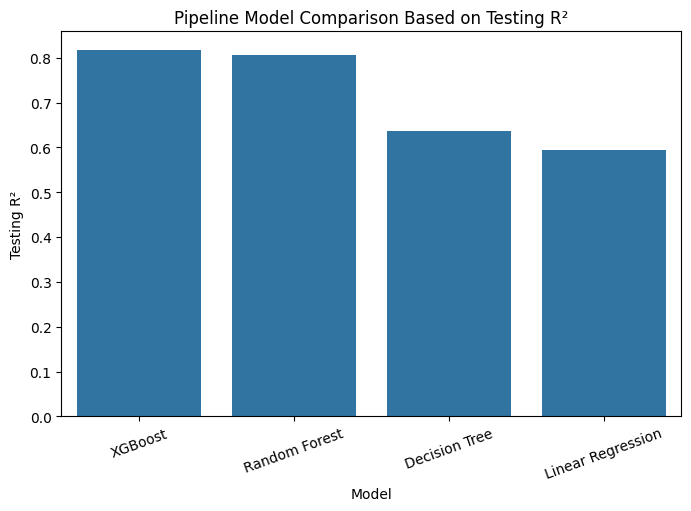

In [135]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=pipeline_results,
    x="Model",
    y="Testing R²"
)

plt.title("Pipeline Model Comparison Based on Testing R²")

plt.xticks(rotation=20)

plt.show()

# Comparing Without Pipeline vs With Pipeline

In [136]:
final_comparison = pd.DataFrame({

    "Metric":[
        "Training R²",
        "Testing R²",
        "MAE",
        "MSE",
        "RMSE"
    ],

    "Without Pipeline":[
        best_train_r2,
        best_test_r2,
        best_mae,
        best_mse,
        best_rmse
    ],

    "With Pipeline":[
        xgb_train_r2_pipe,
        xgb_test_r2_pipe,
        xgb_mae_pipe,
        xgb_mse_pipe,
        xgb_rmse_pipe
    ]

})

final_comparison

,Metric,Without Pipeline,With Pipeline
0,Training R²,0.854369,0.857161
1,Testing R²,0.818603,0.817763
2,MAE,3.188330,3.197432
3,MSE,16.128050,16.202717
4,RMSE,4.015974,4.025260


## Cross Validation (Pipeline)

### Performing Cross Validation

In [137]:
pipeline_cv_scores = cross_val_score(
    
    estimator=xgb_pipeline,
    
    X=X_train,
    
    y=y_train,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

pipeline_cv_scores

array([0.80543113, 0.80911732, 0.81378031, 0.81797618, 0.81377608])

### Mean CV Score

In [138]:
print("Cross Validation Scores")

print(pipeline_cv_scores)

print()

print("Mean CV Score :", round(pipeline_cv_scores.mean(),4))

print("Standard Deviation :", round(pipeline_cv_scores.std(),4))

Cross Validation Scores
[0.80543113 0.80911732 0.81378031 0.81797618 0.81377608]

Mean CV Score : 0.812
Standard Deviation : 0.0043


## Hyperparameter Tuning (With Pipeline)

### Parameter Grid

In [139]:
param_grid_pipeline = {

    "model__n_estimators":[100,200,300],

    "model__learning_rate":[0.05,0.1,0.2],

    "model__max_depth":[3,5,7],

    "model__subsample":[0.8,1.0],

    "model__colsample_bytree":[0.8,1.0]

}

### RandomizedSearchCV

In [140]:
pipeline_random_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=param_grid_pipeline,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

### Best Parameters

In [141]:
pipeline_random_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategi

In [142]:
print("Best Parameters")

print(pipeline_random_search.best_params_)

Best Parameters
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


### Best Pipeline

In [143]:
best_pipeline = pipeline_random_search.best_estimator_

### Final Predictions

In [144]:
pipeline_train_pred = best_pipeline.predict(X_train)

pipeline_test_pred = best_pipeline.predict(X_test)

### Final Evaluation

In [145]:
pipeline_train_r2 = r2_score(
    y_train,
    pipeline_train_pred
)

pipeline_test_r2 = r2_score(
    y_test,
    pipeline_test_pred
)

pipeline_mae = mean_absolute_error(
    y_test,
    pipeline_test_pred
)

pipeline_mse = mean_squared_error(
    y_test,
    pipeline_test_pred
)

pipeline_rmse = np.sqrt(
    pipeline_mse
)

# Final Comparison

In [146]:
final_comparison = pd.DataFrame({

    "Metric":[
        "Training R²",
        "Testing R²",
        "MAE",
        "MSE",
        "RMSE"
    ],

    "Without Pipeline":[
        best_train_r2,
        best_test_r2,
        best_mae,
        best_mse,
        best_rmse
    ],

    "With Pipeline":[
        pipeline_train_r2,
        pipeline_test_r2,
        pipeline_mae,
        pipeline_mse,
        pipeline_rmse
    ]

})

final_comparison

,Metric,Without Pipeline,With Pipeline
0,Training R²,0.854369,0.843982
1,Testing R²,0.818603,0.815028
2,MAE,3.188330,3.226138
3,MSE,16.128050,16.445871
4,RMSE,4.015974,4.055351


## Refit the Final Pipeline

In [148]:
best_pipeline.fit(X, y)

print("Final Pipeline trained successfully on the complete dataset.")

Final Pipeline trained successfully on the complete dataset.


# Saving the Final Pipeline

In [149]:
import pickle

In [150]:
import pickle
pickle.dump(best_pipeline,open("swiggy_delivery_pipeline.pkl", "wb"))
print("Pipeline saved successfully!")

Pipeline saved successfully!


## Final Cleaned CSV

In [151]:
df1.to_csv("swiggy_cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [152]:
import os

print(os.getcwd())

C:\Users\mafai\Mafaiz (Innomatics)\Machine Learning New\ML Projects
